<a href="https://colab.research.google.com/github/Nischay-verma/Specialization--Capstone-3--Integrated-Retail-Analytics-/blob/main/Specialization_Capstone_Module_3_Integrated_Retail_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual


# **Project Summary -**

This project focuses on leveraging data analytics and machine learning to improve retail business performance and decision-making. The primary objective is to analyze historical sales data, identify meaningful patterns, and generate accurate sales forecasts to support strategic planning.

We begin by cleaning and preparing the data to ensure accuracy and reliability. Through exploratory data analysis, we identify seasonal trends, peak sales periods, and unusual patterns in store performance. Stores and departments are grouped based on similar sales behavior to better understand performance differences and opportunities.

Using machine learning models, we forecast weekly sales by incorporating key factors such as promotions, discounts, store type, fuel prices, and economic indicators. These predictions help in anticipating demand fluctuations and improving operational efficiency.

Based on the insights generated, we provide actionable recommendations for inventory management, marketing strategies, and demand planning. The ultimate goal of this project is to transform raw sales data into meaningful insights that enable smarter, data-driven retail decisions.


# **GitHub Link -**

https://github.com/Nischay-verma/Specialization--Capstone-3--Integrated-Retail-Analytics-

# **Problem Statement**


Retail businesses often struggle with accurately forecasting sales due to fluctuating demand, seasonal trends, promotional activities, and external economic factors. Inaccurate predictions can lead to overstocking, stockouts, revenue loss, and inefficient inventory management.

The challenge is to analyze historical sales data and identify patterns that influence store performance. There is a need to build a reliable forecasting model that considers multiple variables such as discounts, store type, and external economic conditions to predict future sales more accurately.

This project aims to solve this problem by using data analytics and machine learning techniques to generate actionable insights and improve sales forecasting, inventory planning, and overall business decision-making.



# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [5]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.cluster import KMeans

# Data preprocessing & evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, silhouette_score

### Dataset Loading

In [6]:
# Load weekly sales data
sales = pd.read_csv('sales data-set.csv')

# Load external features (economic indicators, markdowns)
features = pd.read_csv('Features data set.csv')

# Load store metadata
stores = pd.read_csv('stores data-set.csv')



### Dataset First View

In [7]:
sales.head()   #First 5 Row Sales Data

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [8]:
features.head()  #First 5 Row Features Data

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [9]:
stores.head()   #First 5 Row Store Data

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


### Dataset Rows & Columns count

In [10]:
# Rows & Column Counts
print('Sales data-set shape:', sales.shape)
print('Features data-set shape:', features.shape)
print('Stores data-set shape:', stores.shape)

Sales data-set shape: (421570, 5)
Features data-set shape: (8190, 12)
Stores data-set shape: (45, 3)


### Dataset Information

In [11]:
sales.info()  # Sales Data Info


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [12]:
features.info()   # Feature Data Info


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [13]:
stores.info()  # Store Data Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count

### Merge Datasets

In [ ]:
# Merge sales with features using Store & Date
data = sales.merge(features, on=['Store','Date'], how='left')

# Merge with store information
data = data.merge(stores, on='Store', how='left')

# Convert Date column to datetime format, specifying dayfirst=True
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

# Check structure of merged dataset
data.info()

#### Missing Values/Null Values

In [ ]:
# Identify all markdown-related columns
markdown_cols = [col for col in data.columns if 'MarkDown' in col]

# Fill missing markdown values with 0 (no promotion)
data[markdown_cols] = data[markdown_cols].fillna(0)

# Extract time-based features
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Week'] = data['Date'].dt.isocalendar().week

# Check remaining missing values
data.isnull().sum()

In [ ]:
# Visualizing the missing values

Data Cleaning

Anamoly detection

In [ ]:
iso = IsolationForest(contamination=0.02, random_state=42)

# Fit model on Weekly Sales
data['Anomaly'] = iso.fit_predict(data[['Weekly_Sales']])

# Extract anomalous records
anomalies = data[data['Anomaly'] == -1]

# View sample anomalies
anomalies[['Store','Dept','Weekly_Sales']].head()

,Store,Dept,Weekly_Sales
618,1,5,85676.09
903,1,7,96198.12
904,1,7,166697.72
956,1,7,119302.15
5118,1,38,115564.35


In [ ]:
# Dataset Describe

## ***2. Understanding Your Variables***

### Variables Description

Answer Here

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

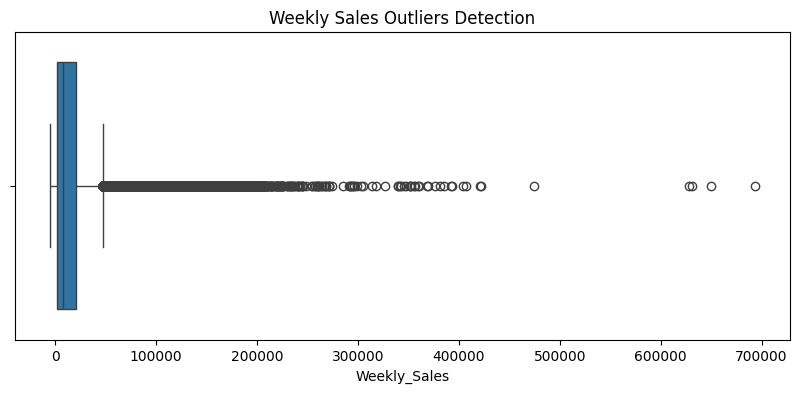

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(x=data['Weekly_Sales'])
plt.title("Weekly Sales Outliers Detection")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

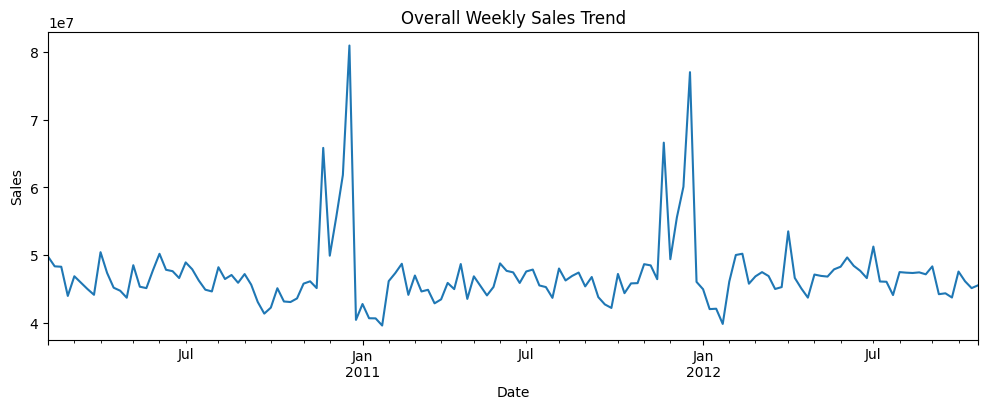

In [ ]:
# Overall weekly sales trend
plt.figure(figsize=(12,4))
data.groupby('Date')['Weekly_Sales'].sum().plot()
plt.title("Overall Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

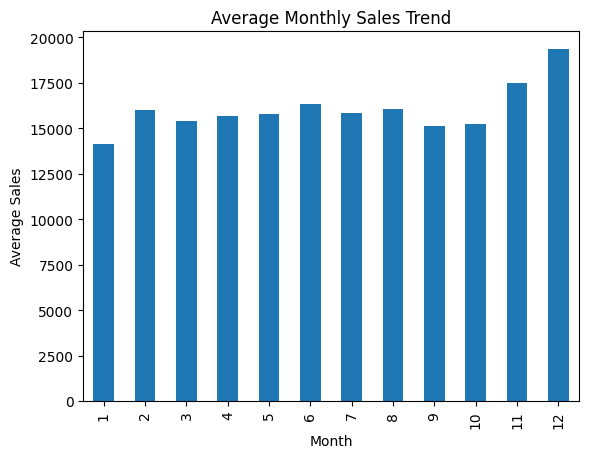

In [ ]:
# Monthly seasonality analysis
monthly_sales = data.groupby('Month')['Weekly_Sales'].mean()

monthly_sales.plot(
    kind='bar',
    title='Average Monthly Sales Trend',
    ylabel='Average Sales'
)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

🔹 7. Store Segmentation Using Clustering

In [ ]:
# Aggregate store-level metrics
segment_data = data.groupby('Store')[[
    'Weekly_Sales','Fuel_Price','CPI','Unemployment'
]].mean()

# Standardize features for clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(segment_data)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
segment_data['Cluster'] = kmeans.fit_predict(scaled_data)

# Preview clusters
segment_data.head()

,Weekly_Sales,Fuel_Price,CPI,Unemployment,Cluster
Store,,,,,
1,21710.543621,3.218811,215.995525,7.610918,1
2,26898.070031,3.219898,215.651869,7.623279,1
3,6373.033983,3.219112,219.402843,7.175602,2
4,29161.210415,3.216237,128.680070,5.965849,1
5,5053.415813,3.220912,216.576516,6.296549,2


✔ Segmentation Quality Evaluation

In [ ]:
# Calculate silhouette score to evaluate clustering
silhouette_score(scaled_data, segment_data['Cluster'])

np.float64(0.32349273141431534)

#### Chart - 4 cluster visualization

In [ ]:
# Aggregate store-level metrics
segment_data = data.groupby('Store')[[
    'Weekly_Sales','Fuel_Price','CPI','Unemployment'
]].mean()

# Standardize features for clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(segment_data)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
segment_data['Cluster'] = kmeans.fit_predict(scaled_data)

# Preview clusters
segment_data.head()

,Weekly_Sales,Fuel_Price,CPI,Unemployment,Cluster
Store,,,,,
1,21710.543621,3.218811,215.995525,7.610918,1
2,26898.070031,3.219898,215.651869,7.623279,1
3,6373.033983,3.219112,219.402843,7.175602,2
4,29161.210415,3.216237,128.680070,5.965849,1
5,5053.415813,3.220912,216.576516,6.296549,2


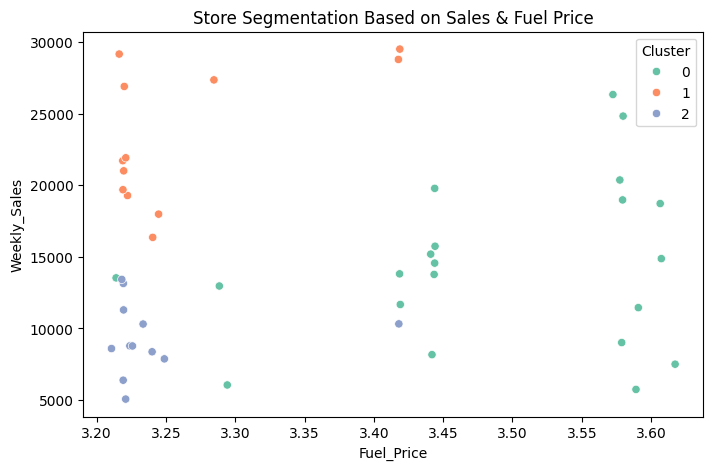

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=segment_data['Fuel_Price'],
    y=segment_data['Weekly_Sales'],
    hue=segment_data['Cluster'],
    palette='Set2'
)
plt.title("Store Segmentation Based on Sales & Fuel Price")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

🔹 8. Market Basket Analysis (Department Associations)

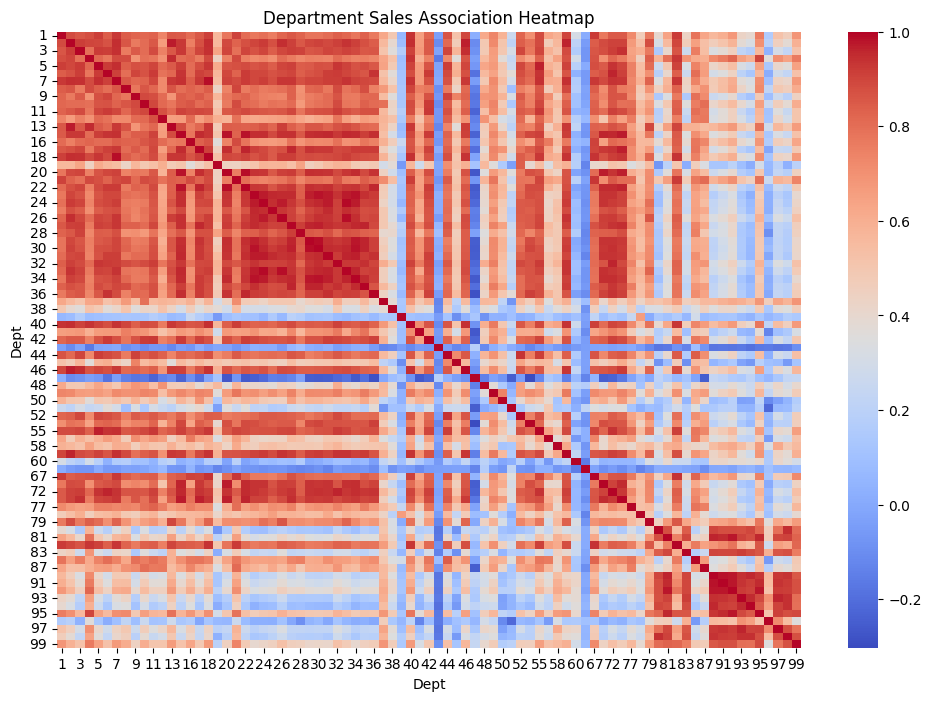

In [ ]:
# Create Store-Department sales matrix
dept_matrix = data.pivot_table(
    index='Store',
    columns='Dept',
    values='Weekly_Sales',
    aggfunc='sum'
).fillna(0)

# Compute correlation between departments
dept_corr = dept_matrix.corr()

# Visualize department associations
plt.figure(figsize=(12,8))
sns.heatmap(dept_corr, cmap='coolwarm')
plt.title("Department Sales Association Heatmap")
plt.show()

🔹 9. Demand Forecasting Model

In [ ]:
# Select features for forecasting
features_model = [
    'Store','Dept','Fuel_Price','CPI','Unemployment','Month','Week'
]

# Split features and target
X = data[features_model]
y = data['Weekly_Sales']

# Convert categorical variables to numeric
X = pd.get_dummies(X, columns=['Store','Dept'], drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [ ]:
# Import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Train Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(X_train, y_train)

# Generate predictions
preds_gbr = gbr.predict(X_test)

# Evaluate model performance
mae_gbr = mean_absolute_error(y_test, preds_gbr)
print(f"Mean Absolute Error (Gradient Boosting Regressor): {mae_gbr}")

Mean Absolute Error (Gradient Boosting Regressor): 9842.327178451445


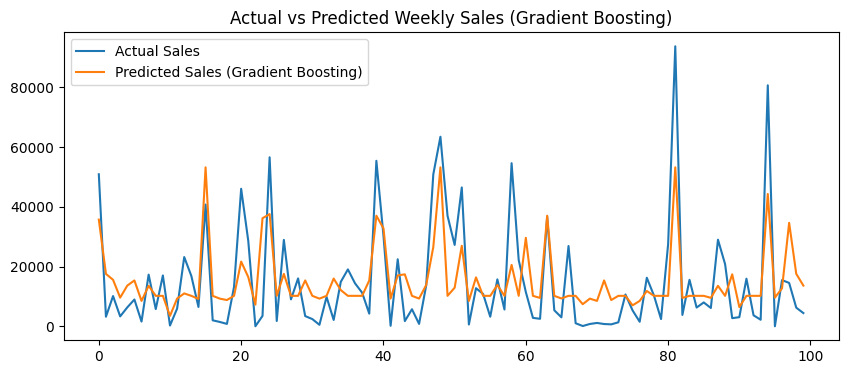

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values[:100], label='Actual Sales')
plt.plot(preds_gbr[:100], label='Predicted Sales (Gradient Boosting)')
plt.legend()
plt.title("Actual vs Predicted Weekly Sales (Gradient Boosting)")
plt.show()

#### Chart - 5 🔹 10. Forecast vs Actual Visualization

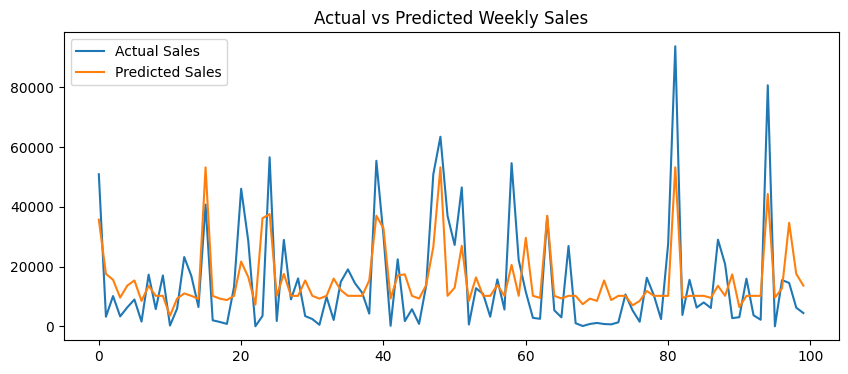

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values[:100], label='Actual Sales')
plt.plot(preds_gbr[:100], label='Predicted Sales')
plt.legend()
plt.title("Actual vs Predicted Weekly Sales")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6 🔹 11. Impact of External Factors

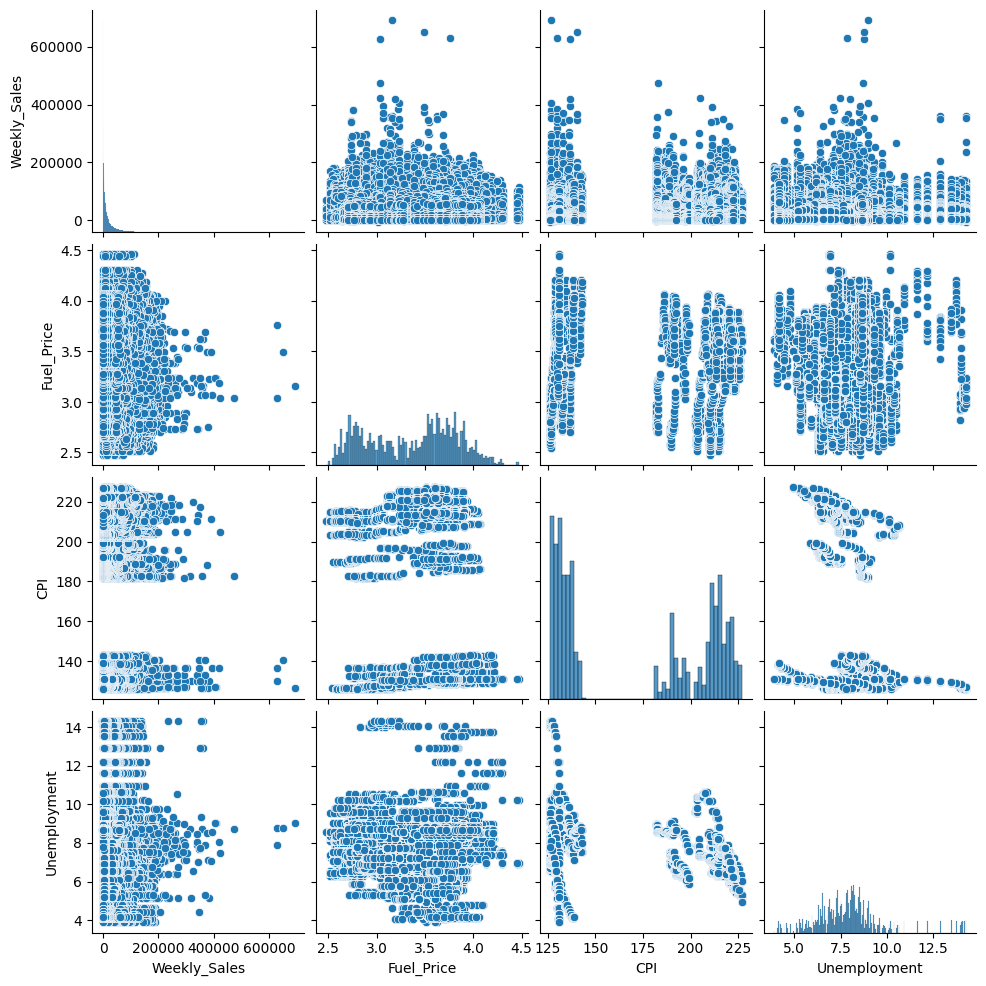

In [ ]:
# Analyze relationships between economic indicators and sales
sns.pairplot(
    data[['Weekly_Sales','Fuel_Price','CPI','Unemployment']]
)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

### Business Insights
- Sales anomalies align with holidays and heavy markdowns
- Fuel price and CPI significantly influence weekly demand
- Store segmentation enables targeted promotions
- ML-based forecasting improves inventory planningWrite the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***